<a href="https://colab.research.google.com/github/shuhei-kuroiwa/cml_study_log/blob/main/PM3/python-functional-approximation-by-nn-and-rf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.neural_network import MLPRegressor

# Function Approximations by Trees and Neural Networks

Here we show how the function
$$
x \mapsto exp(4 x)
$$
can be easily approximated by a tree-based methods (Trees, Random Forest) and a neural network (2 Layered Neural Network)

In [2]:
# noiseless data
def gen_data(n):
    X = np.random.uniform(0, 1, size=(n, 1))
    y = np.exp(4 * X[:, 0])
    return X, y

In [3]:
np.random.seed(123)
X, y = gen_data(1000)

# Functional Approximation by a Tree


In [4]:
tr = DecisionTreeRegressor(ccp_alpha=0.2).fit(X, y)
ypred = tr.predict(X)

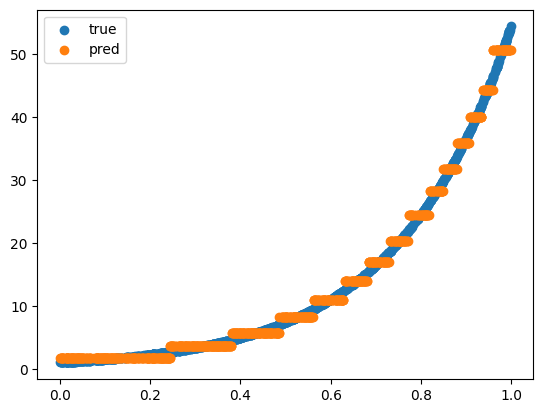

In [5]:
plt.scatter(X[:, 0], y, label='true')
plt.scatter(X[:, 0], ypred, label='pred')
plt.legend()
plt.show()

In [6]:
tr = DecisionTreeRegressor(ccp_alpha=0.001).fit(X, y)
ypred = tr.predict(X)

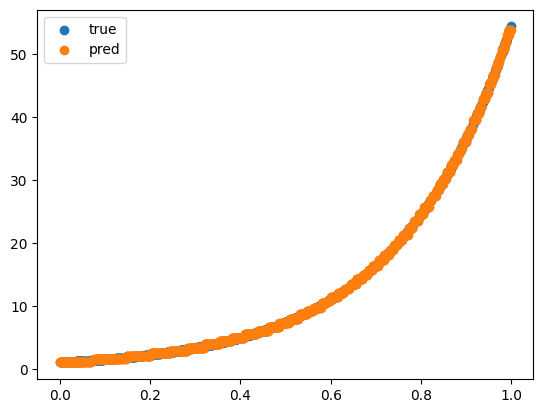

In [7]:
plt.scatter(X[:, 0], y, label='true')
plt.scatter(X[:, 0], ypred, label='pred')
plt.legend()
plt.show()

# Functional Approximation by RF

Here we show how the function
$$
x \mapsto exp(4 x)
$$
can be easily approximated by a tree-based method (Random Forest) and a neural network (2 Layered Neural Network)

In [8]:
rf = RandomForestRegressor().fit(X, y)
ypred = rf.predict(X)

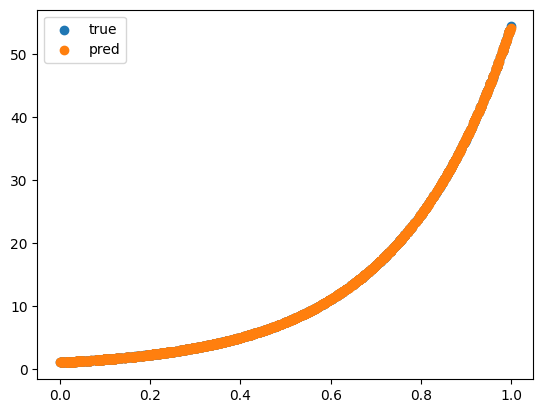

In [9]:
plt.scatter(X[:, 0], y, label='true')
plt.scatter(X[:, 0], ypred, label='pred')
plt.legend()
plt.show()

# Boosted Trees

In [10]:
gbf = GradientBoostingRegressor(n_estimators=100, learning_rate=0.01).fit(X, y)
ypred = gbf.predict(X)

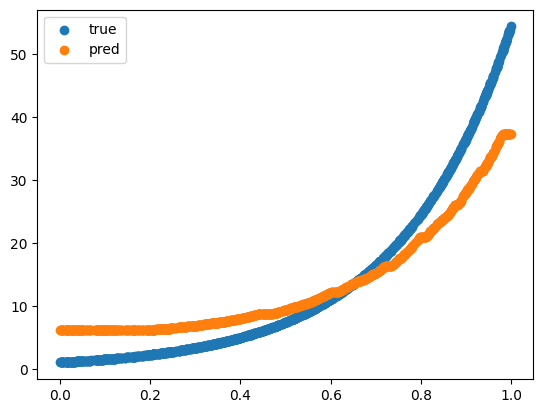

In [11]:
plt.scatter(X[:, 0], y, label='true')
plt.scatter(X[:, 0], ypred, label='pred')
plt.legend()
plt.show()

In [12]:
gbf = GradientBoostingRegressor(n_estimators=1000, learning_rate=0.01).fit(X, y)
ypred = gbf.predict(X)

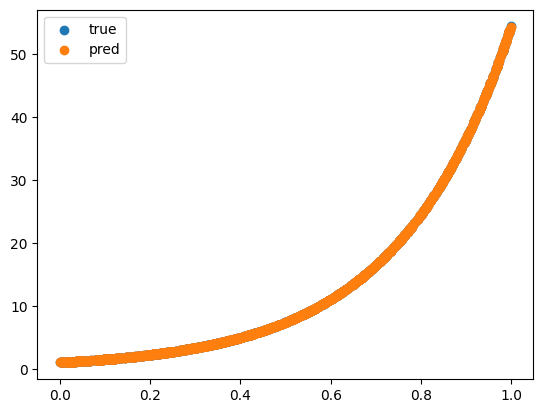

In [13]:
plt.scatter(X[:, 0], y, label='true')
plt.scatter(X[:, 0], ypred, label='pred')
plt.legend()
plt.show()

# Same Example with a Neural Network

In [ ]:
nnet = MLPRegressor((200, 20,), 'relu',
                    learning_rate_init=0.01,
                    batch_size=10, max_iter=1)
nnet

In [ ]:
nnet.fit(X, y)
ypred = nnet.predict(X)

In [ ]:
plt.scatter(X[:, 0], y, label='true')
plt.scatter(X[:, 0], ypred, label='pred')
plt.legend()
plt.show()

In [ ]:
nnet.max_iter = 100
nnet.fit(X, y)
ypred = nnet.predict(X)

In [ ]:
plt.scatter(X[:, 0], y, label='true')
plt.scatter(X[:, 0], ypred, label='pred')
plt.legend()
plt.show()

### Using the PyTorch Neural Network Library and its Sklearn API Skorch

We first need to install skorch.

In [ ]:
!pip install skorch

In [ ]:
import skorch
from skorch import NeuralNetRegressor
import torch
import torch.nn as nn

In [ ]:
arch = nn.Sequential(nn.Linear(X.shape[1], 200), nn.ReLU(),
                     nn.Linear(200, 20), nn.ReLU(),
                     nn.Linear(20, 1))
nnet = NeuralNetRegressor(arch, lr=0.01, batch_size=10, max_epochs=1,
                          optimizer=torch.optim.Adam, train_split=None)
nnet

In [ ]:
nnet.fit(X.astype(np.float32), y.reshape(-1, 1).astype(np.float32))
ypred = nnet.predict(X.astype(np.float32))

In [ ]:
plt.scatter(X[:, 0], y, label='true')
plt.scatter(X[:, 0], ypred, label='pred')
plt.legend()
plt.show()

In [ ]:
nnet.max_epochs = 100  # training for more
nnet.fit(X.astype(np.float32), y.reshape(-1, 1).astype(np.float32))
ypred = nnet.predict(X.astype(np.float32))

In [ ]:
plt.scatter(X[:, 0], y, label='true')
plt.scatter(X[:, 0], ypred, label='pred')
plt.legend()
plt.show()

In [ ]:
# adding early stopping based on validation set performance
nnet.train_split = skorch.dataset.ValidSplit(5)  # 20% validation
nnet.callbacks = [skorch.callbacks.EarlyStopping()]  # early stopping callback

In [ ]:
nnet.fit(X.astype(np.float32), y.reshape(-1, 1).astype(np.float32))
ypred = nnet.predict(X.astype(np.float32))

In [ ]:
plt.scatter(X[:, 0], y, label='true')
plt.scatter(X[:, 0], ypred, label='pred')
plt.legend()
plt.show()